In [1]:
%load_ext autoreload
%autoreload 2

In [36]:
import pandas as pd
import numpy as np
import UpROOT.io as io
import UpROOT.config as conf
import UpROOT.physics.delphes as ph
import UpROOT.plotting.delphes as pt
import UpROOT.pipelines.delphes as pl
import UpROOT.fitting.delphes as fi
import UpROOT.delphes_root as dr

In [3]:
ANALYSIS = 'p01_70GeV'
cfg = conf.CONFIGURATIONS[ANALYSIS]
DATASET = cfg['raw_dataset']
PDATASET = cfg['flat_dataset']
PLOT_DATA = cfg['plot_data']
TARGET_MASS = cfg['target_mass']
MASS_RANGE = cfg['mass_range']
FIT_WINDOW = cfg['fit_window']
MIN_MUON_PT = 0.0
ETA_RANGE = (2.0, 5.0)

plot_options = {
    'save': True,
    'data': PLOT_DATA,
    'output_dir': None
}

In [4]:
collections = (
    'EFlowTrack',
    'Electron',
    'Event',
    'Jet',
    'Muon',
    'Particle',
    'Photon',
    'ScalarHT',
    'Track',
    'Weight'
)

In [ ]:
io.load_dataframe(
    branches=io.txt_data("mpmm"),
    dataset=DATASET,
).head()

Ramas cargadas desde: C:\Users\mario\Documents\PF\MadGraph\analysis\mpmm.txt
Cantidad de ramas: 33
Archivo: MG5_pp_mpmm_100k_70GeV_01.root
Árbol seleccionado: Delphes
Archivo: MG5_pp_mpmm_100k_70GeV_02.root
Árbol seleccionado: Delphes
Archivo: MG5_pp_mpmm_100k_70GeV_03.root
Árbol seleccionado: Delphes
Total de eventos: 300,000 eventos


,Event/Event.CrossSection,Event/Event.CrossSectionError,Event/Event.Number,Event/Event.Weight,Jet/Jet.BTag,Jet/Jet.Charge,Jet/Jet.ChargedEnergyFraction,Jet/Jet.Constituents,Jet/Jet.Eta,Jet/Jet.Mass,...,Muon/Muon.IsolationVarRhoCorr,Muon/Muon.PT,Muon/Muon.Particle,Muon/Muon.Phi,Muon/Muon.SumPt,Muon/Muon.SumPtCharged,Muon/Muon.SumPtChargedPU,Muon/Muon.SumPtNeutral,Muon/Muon.T,Muon_size
0,[2.366332769393921],[59158.3203125],[0],[0.04310808330774307],[],[],[],[],[],[],...,"[0.0, 0.0]","[1.4442028999328613, 1.1412245035171509]","[{'ref': 80}, {'ref': 79}]","[0.28182050585746765, -2.909900188446045]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[1.0882267531542311e-08, 1.0405063477492149e-08]",2
1,[4.732665538787842],[0.0],[1],[31726.65234375],[],[],[],[],[],[],...,[0.0],[1.769708275794983],[{'ref': 29}],[2.8597030639648438],[0.0],[0.0],[0.0],[0.0],[1.0290602148188555e-08],1
2,[7.098998546600342],[0.0],[2],[31941.45703125],[],[],[],[],[],[],...,"[0.0, 0.0]","[1.6018954515457153, 1.1485521793365479]","[{'ref': 16}, {'ref': 15}]","[0.6304005980491638, -2.1212830543518066]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[1.0205273959229544e-08, 6.948178032928354e-09]",2
3,[9.465331077575684],[0.0],[3],[42941.40625],[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],0
4,[11.831664085388184],[0.00028760748682543635],[4],[31682.23828125],[],[],[],[],[],[],...,"[0.0, 0.0]","[2.8276143074035645, 1.8647631406784058]","[{'ref': 41}, {'ref': 40}]","[2.5612406730651855, 0.3249083161354065]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[1.066668176008534e-08, 6.830921606137963e-09]",2


In [ ]:
output = dr.convert_dataset(
    dataset=DATASET,
    collections=collections,
    step_size='20 MB',
    object_registry=True,
    overwrite=True,
    create_dimuons=False
)

Ramas internas de ROOT excluidas:
 - EFlowNeutralHadron/EFlowNeutralHadron.fBits
 - EFlowPhoton/EFlowPhoton.fBits
 - EFlowTrack/EFlowTrack.fBits
 - Electron/Electron.fBits
 - Event/Event.fBits
 - FatJet/FatJet.fBits
 - GenJet/GenJet.fBits
 - GenMissingET/GenMissingET.fBits
 - Jet/Jet.fBits
 - MissingET/MissingET.fBits
 - Muon/Muon.fBits
 - Particle/Particle.fBits
 - Photon/Photon.fBits
 - ScalarHT/ScalarHT.fBits
 - Tower/Tower.fBits
 - Track/Track.fBits
 - Weight/Weight.fBits

Archivo de entrada: C:\Users\mario\Documents\PF\data\MG5_pp_mpmm_100k_70GeV_01.root
Eventos: 100,000
Colecciones: EFlowTrack, Electron, Jet, Muon, Particle, Photon, ScalarHT, Track, Weight
 EFlowTracks: 54 ramas; bloques de 20 MB
 Electrons: 18 ramas; bloques de 20 MB
 Jets: 46 ramas; bloques de 20 MB
 Muons: 17 ramas; bloques de 20 MB
 Particles: 23 ramas; bloques de 20 MB
 Photons: 15 ramas; bloques de 20 MB
 ScalarHT: 2 ramas; bloques de 20 MB
 Tracks: 54 ramas; bloques de 20 MB
 Weights: 2 ramas; bloques de 2

In [5]:
# cut = '(Eta < 5.0) & (Eta > 2)'
MUON_BRANCHES = (
    'event_id',
    'object_index',
    'PT',
    'Eta',
    'Phi',
    'Charge',
    'D0',
    'DZ',
    'ErrorD0',
    'ErrorDZ',
    'IsolationVar',
    'Particle_ref'
)

In [6]:
df_events = io.load_dataframe(
    branches=None,
    dataset=PDATASET,
    tree_path='Events',
)
df_events.head()

Archivo: mpmm_70GeV_pandas.root
Árbol seleccionado: Events
Total de eventos: 300,000 eventos


,source_file_id,event_id,source_entry,root_uid,event_number,ReadTime,ProcTime,ProcessID,MPI,event_weight,...,PDF2,n_EFlowTrack,n_Electron,n_Jet,n_Muon,n_Particle,n_Photon,n_ScalarHT,n_Track,n_Weight
0,0,0,0,0,0,0.174753,0.001585,9999,-1,0.043108,...,0.0,5,0,0,2,286,0,1,5,292
1,0,1,1,0,1,0.004387,0.000668,9999,-1,31726.652344,...,0.0,6,0,0,1,173,0,1,6,292
2,0,2,2,0,2,0.000338,0.000269,9999,-1,31941.457031,...,0.0,4,0,0,2,90,0,1,4,292
3,0,3,3,0,3,0.000715,0.001471,9999,-1,42941.406250,...,0.0,4,0,0,0,267,0,1,4,292
4,0,4,4,0,4,0.000595,0.000744,9999,-1,31682.238281,...,0.0,3,0,0,2,209,0,1,3,292


In [7]:
df_muons = io.load_dataframe(
    branches=MUON_BRANCHES,
    dataset=PDATASET,
    tree_path='Muons'
)
df_muons.head(7)

Archivo: mpmm_70GeV_pandas.root
Árbol seleccionado: Muons
Total de eventos: 281,201 eventos


,event_id,object_index,PT,Eta,Phi,Charge,D0,DZ,ErrorD0,ErrorDZ,IsolationVar,Particle_ref
0,0,0,1.444203,1.588587,0.281821,-1,0.000000e+00,0.000000e+00,0.0,0.0,0.0,80
1,0,1,1.141225,1.972527,-2.909900,1,0.000000e+00,0.000000e+00,0.0,0.0,0.0,79
2,1,0,1.769708,2.136832,2.859703,-1,0.000000e+00,0.000000e+00,0.0,0.0,0.0,29
3,2,0,1.601895,-2.314334,0.630401,-1,6.544414e-14,-7.470573e-13,0.0,0.0,0.0,16
4,2,1,1.148552,-0.938239,-2.121283,1,0.000000e+00,0.000000e+00,0.0,0.0,0.0,15
5,4,0,2.827614,-1.723009,2.561241,-1,0.000000e+00,0.000000e+00,0.0,0.0,0.0,41
6,4,1,1.864763,-0.999608,0.324908,1,-3.322348e-14,-7.547673e-13,0.0,0.0,0.0,40


In [11]:
cdf_muons = df_muons.loc[
    df_muons['PT'].ge(MIN_MUON_PT) & 
    df_muons['Eta'].between(*ETA_RANGE)
].copy()
print(f'Muones totales:       {len(df_muons):,}')
print(f'Muones seleccionados: {len(cdf_muons):,}')

Muones totales:       281,201
Muones seleccionados: 26,592


In [12]:
df_muons = ph.calc_four_momentum(df_muons)
df_muons.head()

,event_id,object_index,PT,Eta,Phi,Charge,D0,DZ,ErrorD0,ErrorDZ,IsolationVar,Particle_ref,PX,PY,PZ,P,E
0,0,0,1.444203,1.588587,0.281821,-1,0.000000e+00,0.000000e+00,0.0,0.0,0.0,80,1.387230,0.401640,3.388541,3.683467,3.684982
1,0,1,1.141225,1.972527,-2.909900,1,0.000000e+00,0.000000e+00,0.0,0.0,0.0,79,-1.110730,-0.262054,4.022653,4.181403,4.182737
2,1,0,1.769708,2.136832,2.859703,-1,0.000000e+00,0.000000e+00,0.0,0.0,0.0,29,-1.699861,0.492282,7.392537,7.601412,7.602146
3,2,0,1.601895,-2.314334,0.630401,-1,6.544414e-14,-7.470573e-13,0.0,0.0,0.0,16,1.293997,0.944267,-8.024975,8.183293,8.183975
4,2,1,1.148552,-0.938239,-2.121283,1,0.000000e+00,0.000000e+00,0.0,0.0,0.0,15,-0.600810,-0.978877,-1.242826,1.692273,1.695568


In [13]:
cdf_muons = ph.calc_four_momentum(cdf_muons)
cdf_muons.head()

,event_id,object_index,PT,Eta,Phi,Charge,D0,DZ,ErrorD0,ErrorDZ,IsolationVar,Particle_ref,PX,PY,PZ,P,E
2,1,0,1.769708,2.136832,2.859703,-1,0.0,0.0,0.0,0.0,0.0,29,-1.699861,0.492282,7.392537,7.601412,7.602146
48,45,0,1.171718,2.065295,0.226416,1,0.0,0.0,0.0,0.0,0.0,15,1.141813,0.263035,4.546760,4.695311,4.696500
67,61,0,1.195463,2.144423,0.385404,1,0.0,0.0,0.0,0.0,0.0,28,1.107772,0.449415,5.032889,5.172920,5.173999
78,73,0,2.901314,2.194488,2.786878,-1,0.0,0.0,0.0,0.0,0.0,22,-2.720695,1.007694,12.858607,13.181859,13.182282
82,78,0,2.909660,2.041533,1.327660,-1,0.0,0.0,0.0,0.0,0.0,16,0.700494,2.824080,11.016809,11.394569,11.395059


In [14]:
df_dimuons = ph.prepare_dimuon_analysis(
    df_muons, 
    events=df_events,
    min_muon_pt=MIN_MUON_PT,
    classify_displacement=True,
    prompt_max_significance=3.0,
    displaced_min_significance=5.0
)
df_dimuons.head()

,event_id,muplus_index,muplus_pt,muplus_eta,muplus_phi,muplus_charge,muplus_d0,muplus_dz,muplus_error_d0,muplus_error_dz,...,dimuon_rapidity,cos_theta_star,muplus_d0_significance,muminus_d0_significance,muplus_chi2_ip_proxy,muminus_chi2_ip_proxy,sqrt_min_chi2_ip_proxy,min_chi2_ip_proxy,ip_proxy_valid,displacement_category
0,0,1,1.141225,1.972527,-2.909900,1,0.000000e+00,0.000000e+00,0.0,0.0,...,1.755291,-0.189646,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
1,2,1,1.148552,-0.938239,-2.121283,1,0.000000e+00,0.000000e+00,0.0,0.0,...,-1.721804,-0.596726,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
2,4,1,1.864763,-0.999608,0.324908,1,-3.322348e-14,-7.547673e-13,0.0,0.0,...,-1.431535,-0.346711,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
3,11,1,0.830079,-0.398254,2.855062,1,0.000000e+00,0.000000e+00,0.0,0.0,...,0.552510,0.568433,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
4,12,1,1.071112,-0.073025,2.336287,1,0.000000e+00,0.000000e+00,0.0,0.0,...,-0.908601,-0.443618,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid


In [15]:
display(df_dimuons[[
    "event_id", "dimuon_mass", "dimuon_pt", "delta_r",
    "sqrt_min_chi2_ip_proxy", "min_chi2_ip_proxy",
    "ip_proxy_valid", "displacement_category"
]].head())

,event_id,dimuon_mass,dimuon_pt,delta_r,sqrt_min_chi2_ip_proxy,min_chi2_ip_proxy,ip_proxy_valid,displacement_category
0,0,2.622839,0.309736,3.115215,NaN,NaN,False,invalid
1,2,3.351350,0.694051,3.076589,NaN,NaN,False,invalid
2,4,4.471816,2.227330,2.350424,NaN,NaN,False,invalid
3,11,2.609251,3.096722,1.716789,NaN,NaN,False,invalid
4,12,6.201837,7.935793,2.415721,NaN,NaN,False,invalid


In [16]:
display(
    df_dimuons['displacement_category']
    .value_counts(dropna=False)
    .rename('candidatos')
)

displacement_category
invalid    89700
Name: candidatos, dtype: int64

In [17]:
cdf_dimuons = ph.prepare_dimuon_analysis(
    cdf_muons, 
    events=df_events,
    min_muon_pt=MIN_MUON_PT,
    classify_displacement=True,
    prompt_max_significance=3.0,
    displaced_min_significance=5.0
)
cdf_dimuons.head(7)

,event_id,muplus_index,muplus_pt,muplus_eta,muplus_phi,muplus_charge,muplus_d0,muplus_dz,muplus_error_d0,muplus_error_dz,...,dimuon_rapidity,cos_theta_star,muplus_d0_significance,muminus_d0_significance,muplus_chi2_ip_proxy,muminus_chi2_ip_proxy,sqrt_min_chi2_ip_proxy,min_chi2_ip_proxy,ip_proxy_valid,displacement_category
0,129,0,2.460208,2.160101,0.951638,1,0.0,0.0,0.0,0.0,...,2.154195,-0.005146,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
1,773,0,3.729106,2.050864,-0.548498,1,-0.0,0.0,0.0,0.0,...,2.168234,0.152056,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
2,1382,1,0.934022,2.244327,-0.820332,1,-0.0,0.0,0.0,0.0,...,2.094963,-0.115223,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
3,1495,1,2.837064,2.145798,-1.233737,1,-0.0,0.0,0.0,0.0,...,2.336941,0.135478,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
4,1607,1,6.321775,2.096923,-0.159270,1,-0.0,0.0,0.0,0.0,...,2.103765,0.006848,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
5,1702,1,0.950458,2.220622,2.432603,1,0.0,0.0,0.0,0.0,...,2.111393,-0.062579,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
6,1844,1,1.151559,2.324838,-2.735851,1,0.0,0.0,0.0,0.0,...,2.147786,-0.121603,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\event_multiplicities_70GeV_01.png.


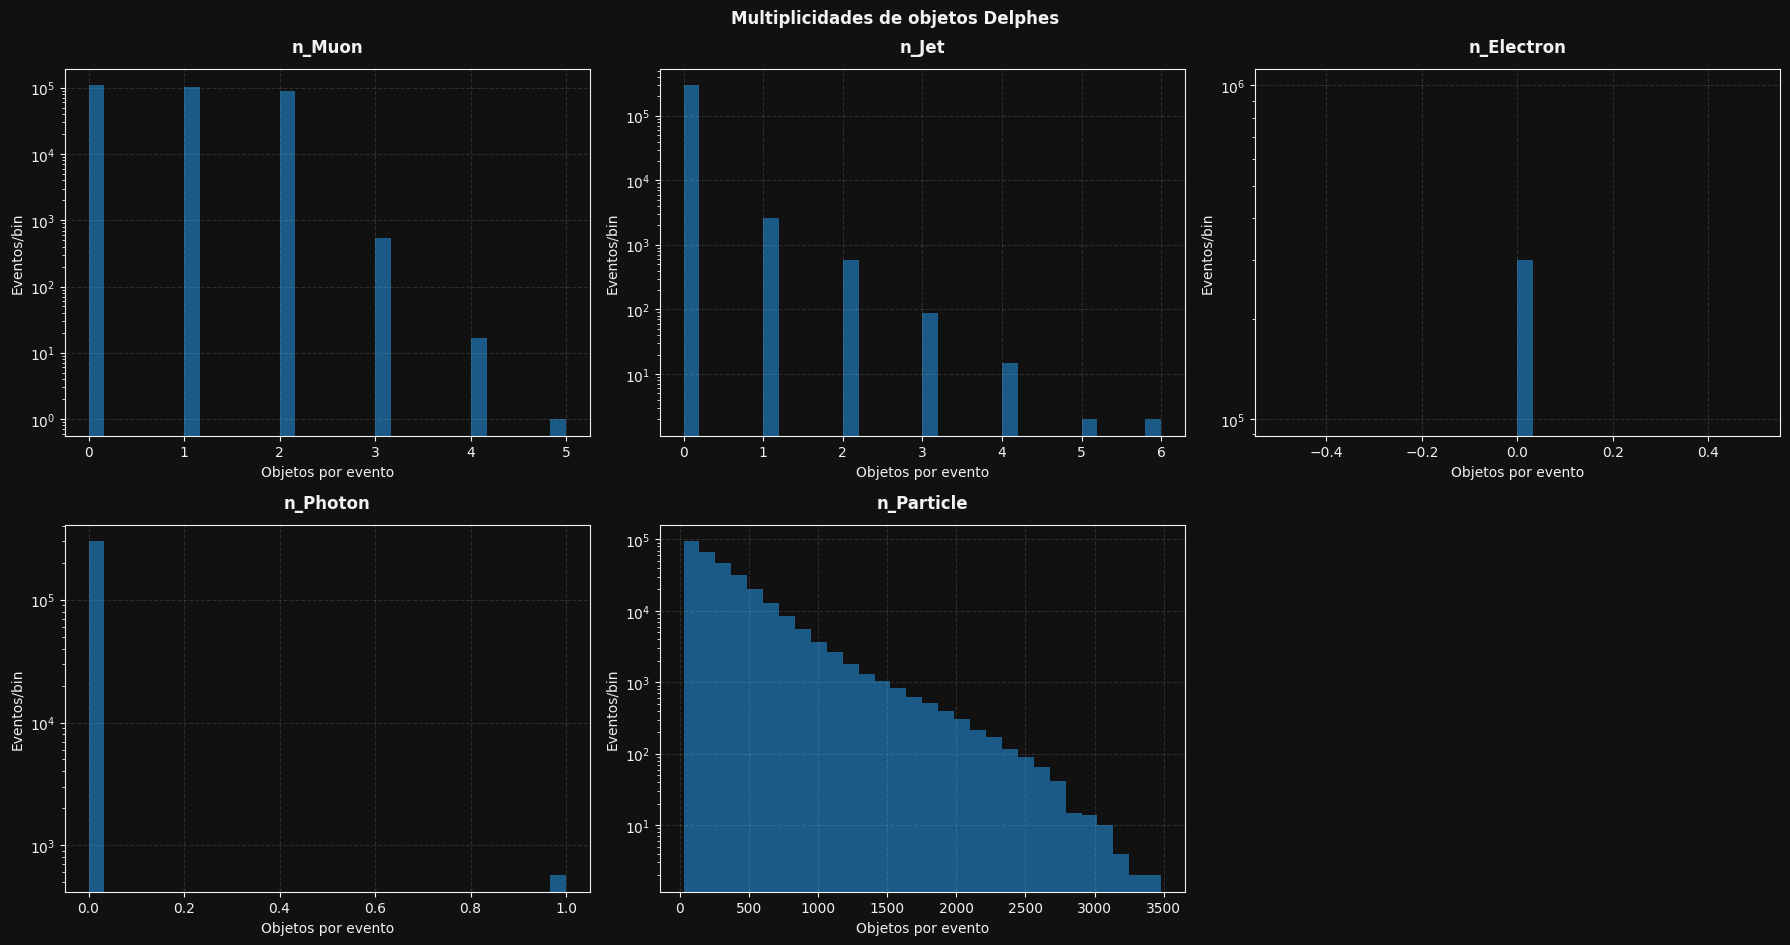

(<Figure size 1800x960 with 6 Axes>,
 array([[<Axes: title={'center': 'n_Muon'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Jet'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Electron'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>],
        [<Axes: title={'center': 'n_Photon'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Particle'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: >]], dtype=object))

In [18]:
pt.plot_event_multiplicities(
    df_events,
    filename='event_multiplicities_70GeV_01',
    **plot_options
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\muon_kinematics_70GeV_01.png.


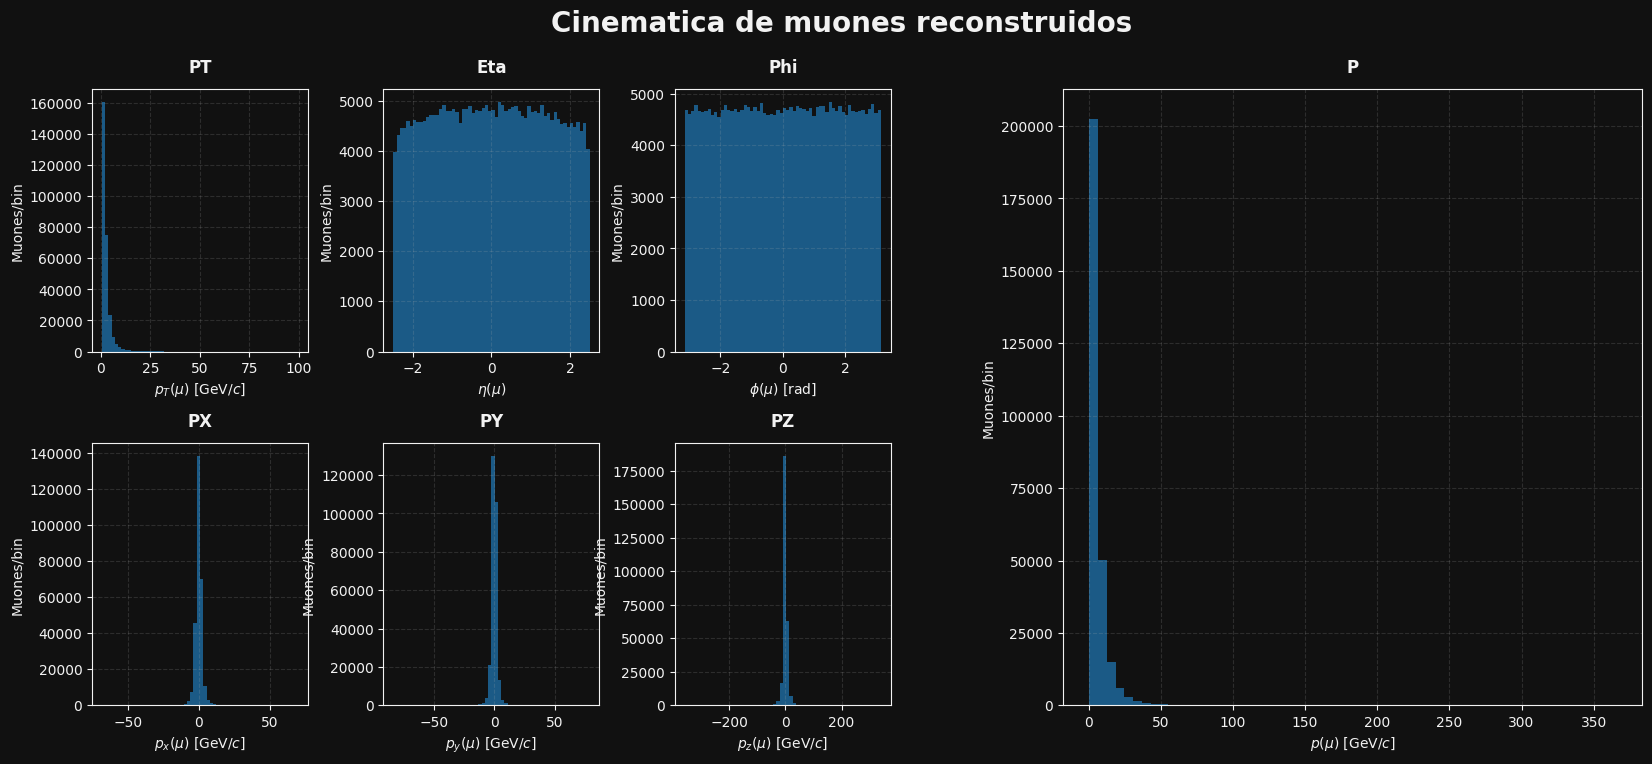

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [19]:
pt.plot_muon_kinematics(
    df_muons, 
    bins=60, 
    filename="muon_kinematics_70GeV_01",
    **plot_options
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\muon_kinematics_70GeV_01_cut.png.


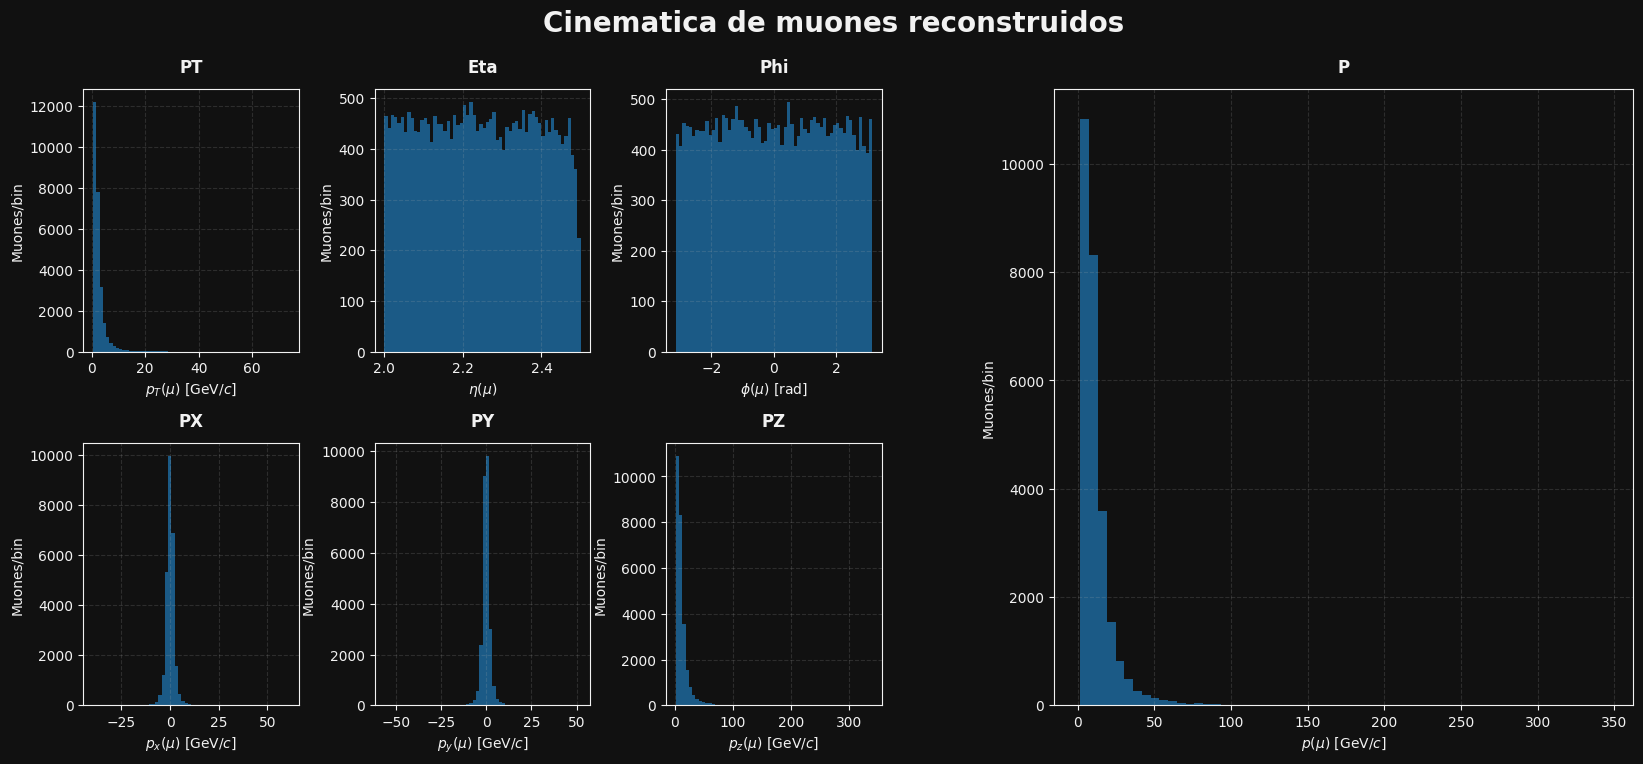

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [20]:
pt.plot_muon_kinematics(
    cdf_muons, 
    bins=60,
    filename="muon_kinematics_70GeV_01_cut",
    **plot_options
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\muon_kinematics_70GeV_02.png.


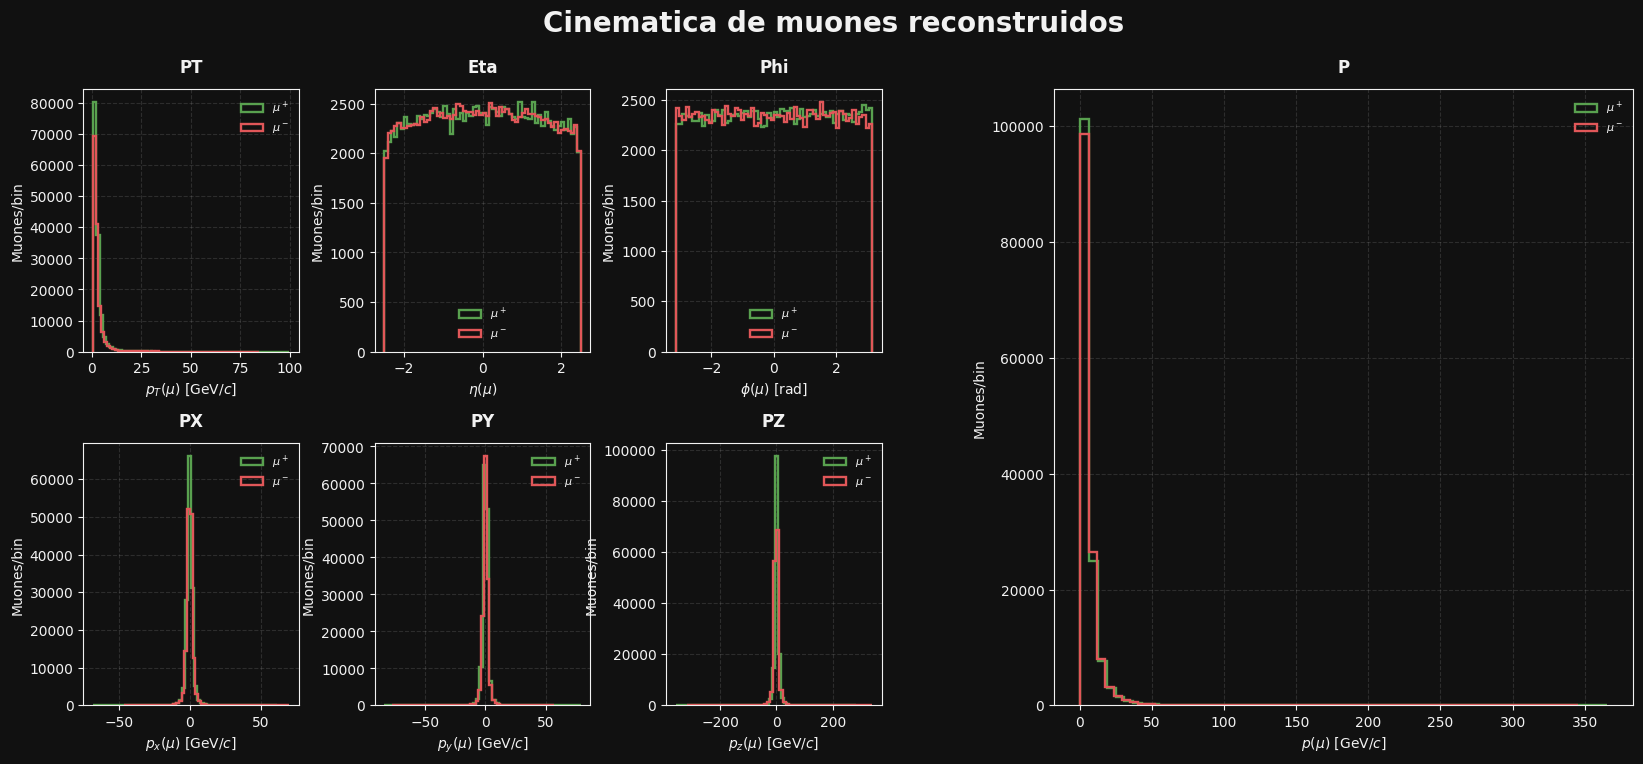

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [21]:
pt.plot_muon_kinematics(
    df_muons, 
    bins=60, 
    split_charge=True, 
    filename="muon_kinematics_70GeV_02",
    **plot_options
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\muon_kinematics_70GeV_02_cut.png.


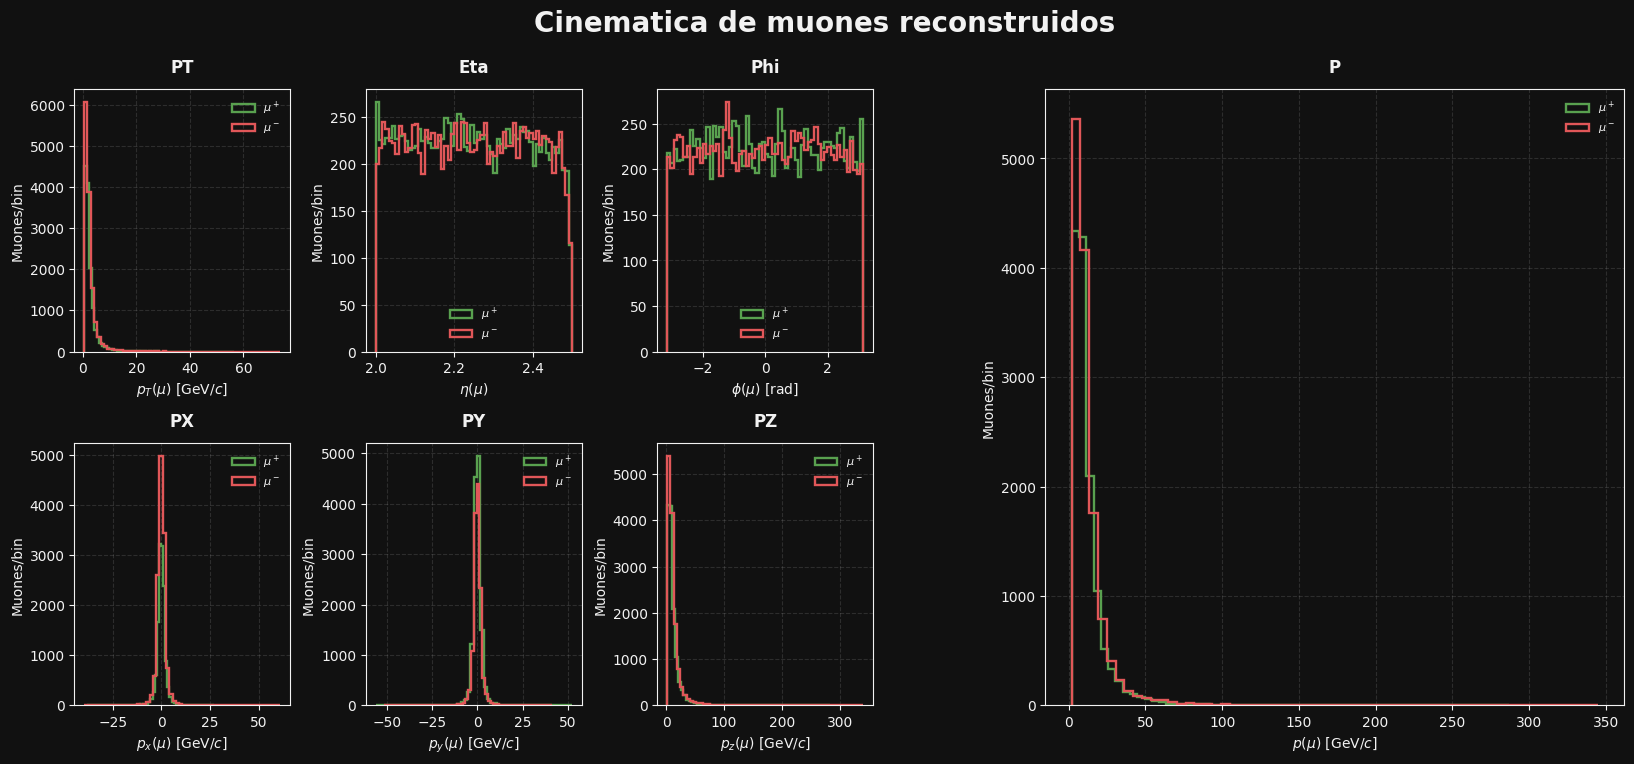

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [22]:
pt.plot_muon_kinematics(
    cdf_muons, 
    bins=60, 
    split_charge=True,
    filename="muon_kinematics_70GeV_02_cut",
    **plot_options
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\dimuon_mass_70GeV_01.png.


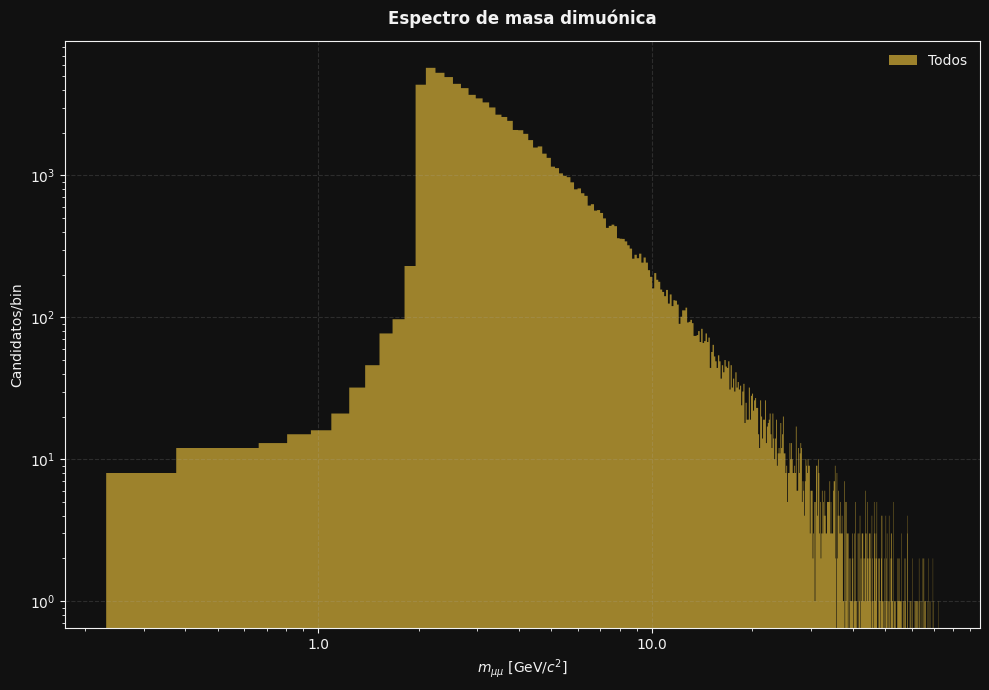

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Espectro de masa dimuónica'}, xlabel='$m_{\\mu\\mu}$ [GeV/$c^2$]', ylabel='Candidatos/bin'>)

In [23]:
pt.plot_dimuon_mass(
    df_dimuons,
    bins=500, 
    log_x=True,
    log_y=True, 
    filename="dimuon_mass_70GeV_01",
    **plot_options
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\dimuon_mass_70GeV_01_cut.png.


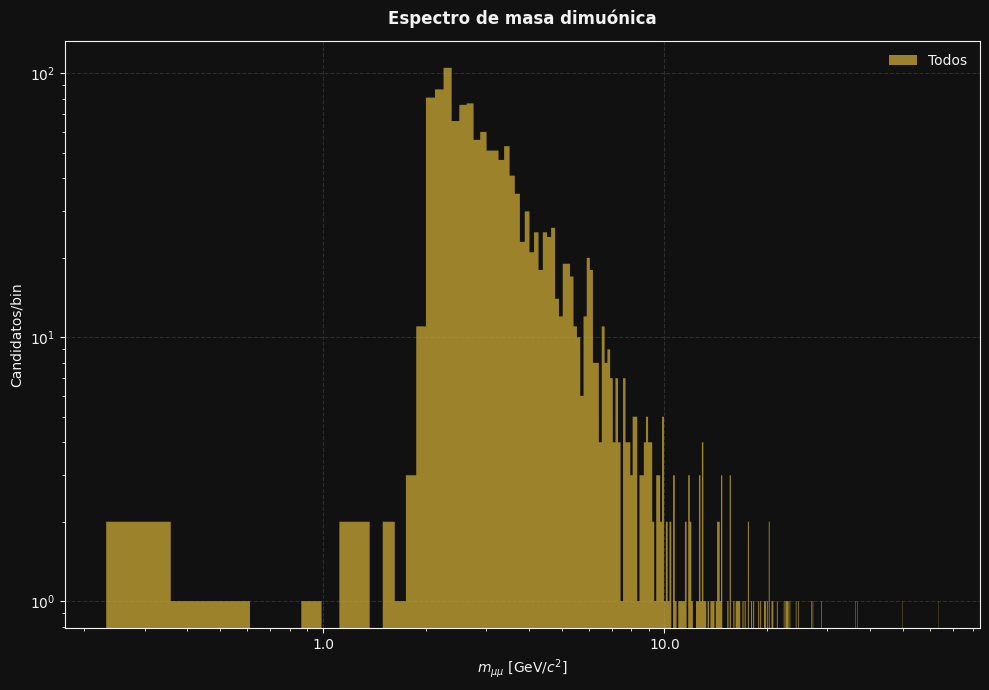

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Espectro de masa dimuónica'}, xlabel='$m_{\\mu\\mu}$ [GeV/$c^2$]', ylabel='Candidatos/bin'>)

In [24]:
pt.plot_dimuon_mass(
    cdf_dimuons, 
    bins=500, 
    log_x=True,
    log_y=True, 
    filename="dimuon_mass_70GeV_01_cut",
    **plot_options
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\disp_dimuon_mass_70GeV_01.png.


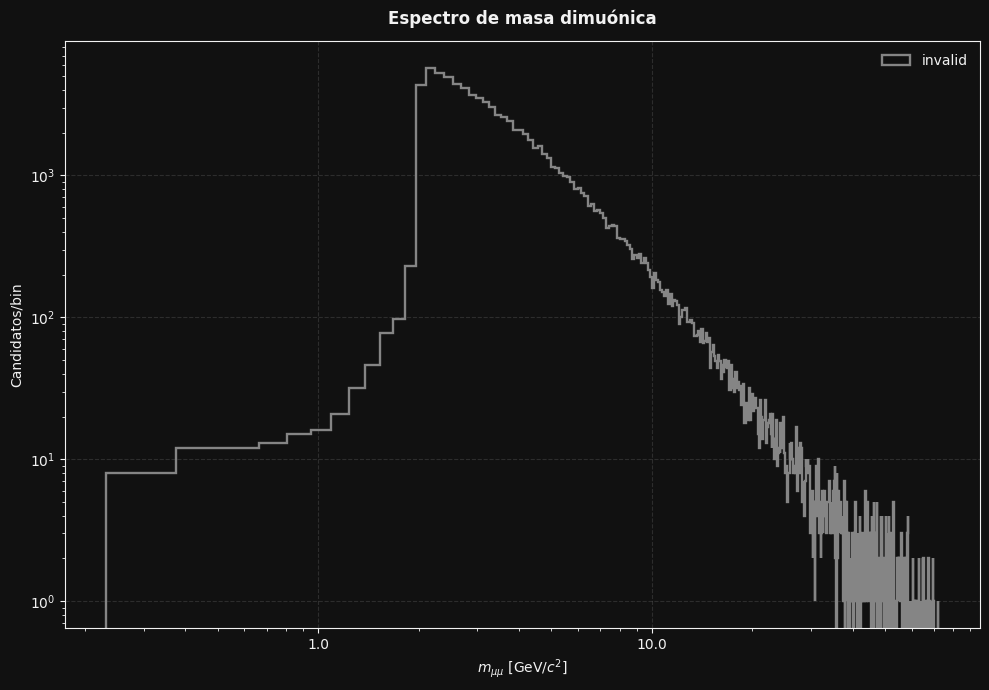

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Espectro de masa dimuónica'}, xlabel='$m_{\\mu\\mu}$ [GeV/$c^2$]', ylabel='Candidatos/bin'>)

In [26]:
pt.plot_dimuon_mass(
    df_dimuons,
    bins=500,
    category_column='displacement_category',
    log_x=True,
    log_y=True,
    filename="disp_dimuon_mass_70GeV_01",
    **plot_options
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\disp_dimuon_mass_70GeV_01_cut.png.


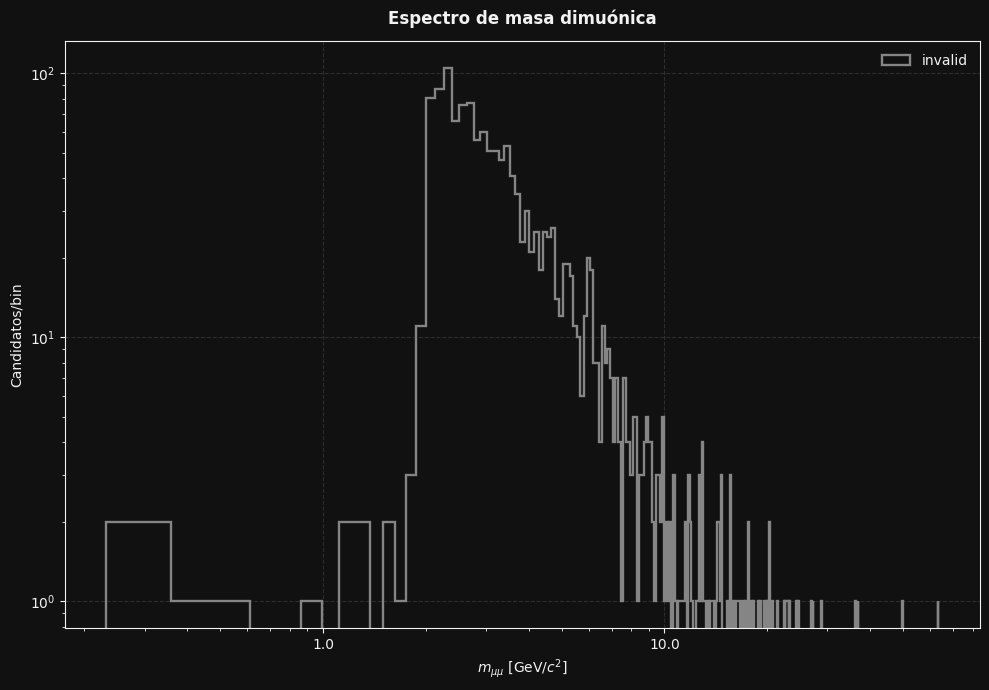

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Espectro de masa dimuónica'}, xlabel='$m_{\\mu\\mu}$ [GeV/$c^2$]', ylabel='Candidatos/bin'>)

In [27]:
pt.plot_dimuon_mass(
    cdf_dimuons,
    bins=500,
    category_column='displacement_category',
    log_x=True,
    log_y=True,
    filename="disp_dimuon_mass_70GeV_01_cut",
    **plot_options
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\p01_70GeV_dimuon_delta_r_01.png.


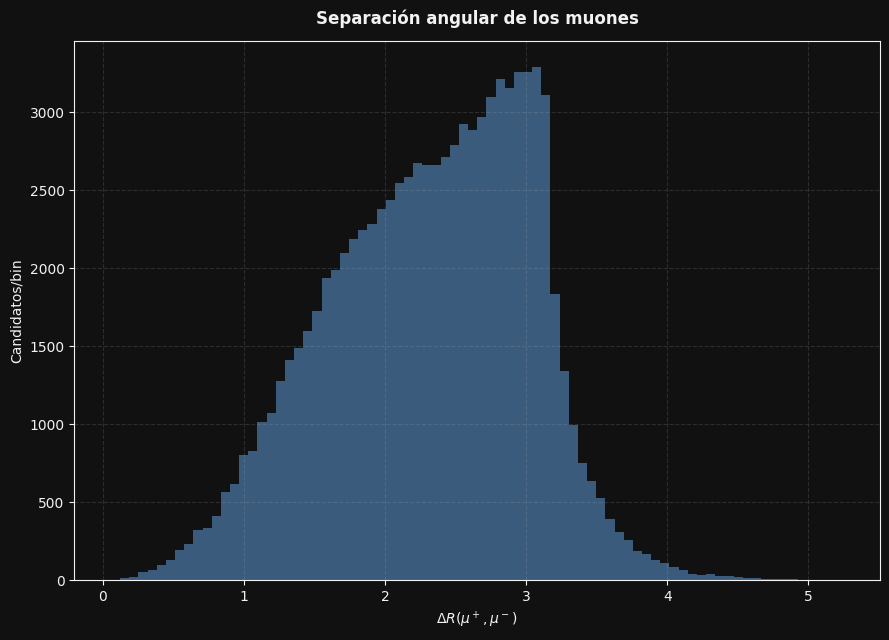

(<Figure size 900x650 with 1 Axes>,
 <Axes: title={'center': 'Separación angular de los muones'}, xlabel='$\\Delta R(\\mu^+,\\mu^-)$', ylabel='Candidatos/bin'>)

In [28]:
pt.plot_dimuon_delta_r(
    df_dimuons,
    bins=80,
    filename=f"{ANALYSIS}_dimuon_delta_r_01",
    **plot_options
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\p01_70GeV_dimuon_delta_r_01_cut.png.


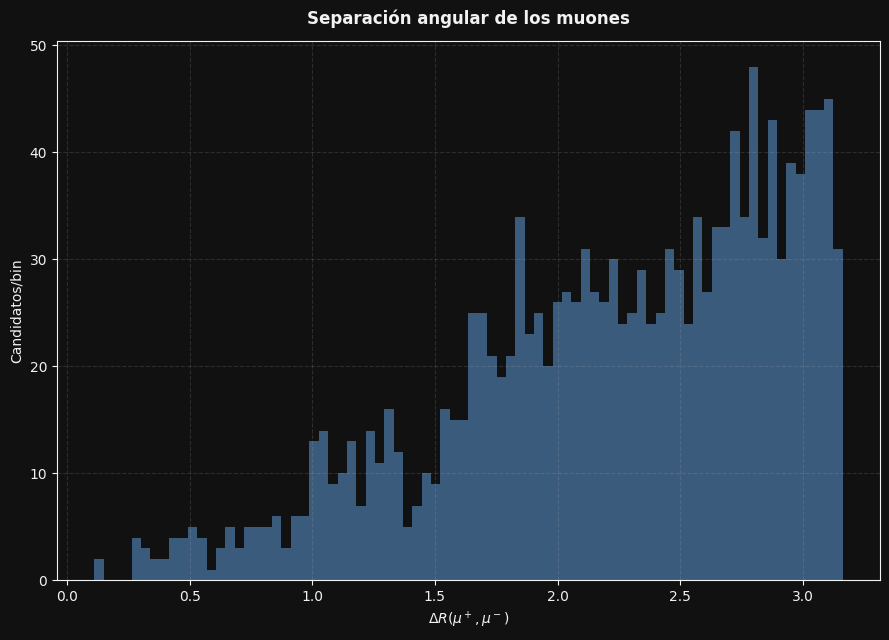

(<Figure size 900x650 with 1 Axes>,
 <Axes: title={'center': 'Separación angular de los muones'}, xlabel='$\\Delta R(\\mu^+,\\mu^-)$', ylabel='Candidatos/bin'>)

In [33]:
pt.plot_dimuon_delta_r(
    cdf_dimuons,
    bins=80,
    # value_range=(0.0, 5.0),
    filename=f"{ANALYSIS}_dimuon_delta_r_01_cut",
    **plot_options
)

In [35]:
daughter_keys = pd.concat(
    [
        df_dimuons[['event_id', 'muplus_particle_ref']].rename(columns={'muplus_particle_ref': 'root_uid'}),
        df_dimuons[['event_id', 'muminus_particle_ref']].rename(columns={'muminus_particle_ref': 'root_uid'})
    ], 
    ignore_index=True
)
daughter_keys = (
    daughter_keys
    .dropna()
    .loc[lambda frame: frame['root_uid'].ne(0)]
    .drop_duplicates()
)
PARTICLE_BRANCHES = (
    'object_index', 'root_uid', 'PID', 'M1', 'M2', 'Mass',
    'X', 'Y', 'Z', 'PT', 'Eta', 'Phi'
)
truth_daughters = io.load_dataframe_for_keys(
    daughter_keys,
    key_columns=('event_id', 'root_uid'),
    branches=PARTICLE_BRANCHES,
    dataset=PDATASET,
    tree_path='Particles'
)

Archivo: mpmm_70GeV_pandas.root
Árbol seleccionado: Particles
Total de filas seleccionadas en Particles: 178,796 filas


In [38]:
mother_keys = (
    truth_daughters[['event_id', 'M1', 'M2']].melt(
        id_vars='event_id',
        value_vars=('M1', 'M2'),
        value_name='object_index'
    )[['event_id', 'object_index']]
)
mother_keys['object_index'] = pd.to_numeric(
    mother_keys['object_index'],
    errors='coerce'
)
mother_keys = (
    mother_keys
    .dropna()
    .loc[lambda frame: frame['object_index'].ge(0)]
    .drop_duplicates()
)
mother_keys['object_index'] = mother_keys['object_index'].astype(np.int64)
truth_parents = io.load_dataframe_for_keys(
    mother_keys,
    key_columns=('event_id', 'object_index'),
    branches=PARTICLE_BRANCHES,
    dataset=PDATASET,
    tree_path='Particles'
)
df_particles_truth = (
    pd.concat(
        [truth_daughters, truth_parents], ignore_index=True
    )
    .drop_duplicates(['event_id', 'object_index'])
    .reset_index(drop=True)
)
print('Particulas truth retenidas:', df_particles_truth.shape)

Archivo: mpmm_70GeV_pandas.root
Árbol seleccionado: Particles
Total de filas seleccionadas en Particles: 178,779 filas
Particulas truth retenidas: (357575, 13)


In [39]:
tdf_dimuons = ph.calc_truth_decay_time(
    df_dimuons,
    df_particles_truth,
    parent_pid=None
)
parent_counts = (
    tdf_dimuons.loc[tdf_dimuons['truth_parent_found'], 'truth_parent_pid']
    .value_counts()
)
display(parent_counts)

truth_parent_pid
23     9
443    3
113    2
221    2
223    1
Name: count, dtype: Int64

In [40]:
n_total = len(tdf_dimuons)
n_parent = int(tdf_dimuons["truth_parent_found"].sum())

print(f"Candidatos totales: {n_total:,}")
print(f"Con madre truth:    {n_parent:,}")
print(f"Fracción:           {n_parent / n_total:.3%}")

Candidatos totales: 89,700
Con madre truth:    17
Fracción:           0.019%


In [42]:
truth_parent_summary = (
    tdf_dimuons.loc[tdf_dimuons["truth_parent_found"]]
    .groupby("truth_parent_pid", dropna=False)
    .agg(
        candidates=("event_id", "size"),
        median_mass=("dimuon_mass", "median"),
        median_truth_time_ps=(
            "dimuon_decay_time_truth_ps",
            "median",
        ),
        median_decay_length_mm=(
            "truth_decay_length_mm",
            "median",
        ),
    )
    .sort_values("candidates", ascending=False)
)

display(truth_parent_summary)

,candidates,median_mass,median_truth_time_ps,median_decay_length_mm
truth_parent_pid,,,,
23,9,63.160581,0.000000,0.000000
443,3,3.108991,0.000000,0.000000
113,2,1.105753,0.000000,0.000000
221,2,0.317508,0.000001,0.000002
223,1,0.264968,0.000000,0.000000


In [44]:
APRIME_PID = None
if APRIME_PID is not None:
    tdf_dimuons = ph.calc_truth_decay_time(
        tdf_dimuons,
        df_particles_truth,
        parent_pid=APRIME_PID
    )
# Verificando decaimientos long-lived
truth_summary = ph.check_long_lived_truth(
    tdf_dimuons,
    minimum_time_ps=0.0,
    minimum_displacement_mm=0.0
)
display(pd.Series(truth_summary))

n_candidates                      89700
n_parent_found                       17
n_finite_time                        17
n_finite_displacement                17
n_long_lived_truth                    2
fraction_long_lived_truth      0.000022
median_decay_time_truth_ps     0.000001
maximum_decay_time_truth_ps    0.000002
has_long_lived_truth               True
dtype: object

In [45]:
# Asociación con tracks y proxies reconstruidos
track_keys = pd.concat(
    [
        tdf_dimuons[['event_id', 'muplus_particle_ref']].rename(columns={'muplus_particle_ref': 'Particle_ref'}),
        tdf_dimuons[['event_id', 'muminus_particle_ref']].rename(columns={'muminus_particle_ref': 'Particle_ref'})
    ], ignore_index=True
)
track_keys = (
    track_keys
    .dropna()
    .loc[lambda frame: frame['Particle_ref'].ne(0)]
    .drop_duplicates()
)
df_tracks = io.load_dataframe_for_keys(
    track_keys,
    key_columns=('event_id', 'Particle_ref'),
    branches=('X', 'Y', 'Z', 'D0', 'DZ', 'ErrorD0', 'ErrorDZ'),
    dataset=PDATASET,
    tree_path='Tracks'
)
df_tracks.head()

Archivo: mpmm_70GeV_pandas.root
Árbol seleccionado: Tracks
Total de filas seleccionadas en Tracks: 178,796 filas


,event_id,Particle_ref,X,Y,Z,D0,DZ,ErrorD0,ErrorDZ
0,0,79,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0
1,0,80,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0
2,2,15,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0
3,2,16,0.0,0.0,0.0,6.544414e-14,-7.470573e-13,0.0,0.0
4,4,40,0.0,0.0,0.0,-3.322348e-14,-7.547673e-13,0.0,0.0


In [46]:
tdf_dimuons = ph.attach_dimuon_track_vertices(tdf_dimuons, df_tracks)
tdf_dimuons.head()

,event_id,muplus_index,muplus_pt,muplus_eta,muplus_phi,muplus_charge,muplus_d0,muplus_dz,muplus_error_d0,muplus_error_dz,...,muplus_track_matched,muminus_track_x,muminus_track_y,muminus_track_z,muminus_track_d0,muminus_track_dz,muminus_track_error_d0,muminus_track_error_dz,muminus_track_matched,dimuon_tracks_matched
0,0,1,1.141225,1.972527,-2.909900,1,0.000000e+00,0.000000e+00,0.0,0.0,...,True,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,True,True
1,2,1,1.148552,-0.938239,-2.121283,1,0.000000e+00,0.000000e+00,0.0,0.0,...,True,0.0,0.0,0.0,6.544414e-14,-7.470573e-13,0.0,0.0,True,True
2,4,1,1.864763,-0.999608,0.324908,1,-3.322348e-14,-7.547673e-13,0.0,0.0,...,True,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,True,True
3,11,1,0.830079,-0.398254,2.855062,1,0.000000e+00,0.000000e+00,0.0,0.0,...,True,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,True,True
4,12,1,1.071112,-0.073025,2.336287,1,0.000000e+00,0.000000e+00,0.0,0.0,...,True,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0,True,True


In [48]:
# Construir resoluciones proxy a partir de las incertidumbres de las trazas
tdf_dimuons['sigma_vertex_xy_proxy_mm'] = np.hypot(
    tdf_dimuons['muplus_track_error_d0'],
    tdf_dimuons['muminus_track_error_d0']
)
tdf_dimuons['sigma_vertex_z_proxy_mm'] = np.hypot(
    tdf_dimuons['muplus_track_error_dz'],
    tdf_dimuons['muminus_track_error_dz']
)
tdf_dimuons['sigma_pointing_proxy_mm'] = np.hypot(
    tdf_dimuons['sigma_vertex_xy_proxy_mm'],
    tdf_dimuons['sigma_vertex_z_proxy_mm']
)

# Calculando el proxi de \chi^{2}_{DF}, vértice secundario proxy y tiempo reconstruido
tdf_dimuons = ph.calc_decay_fit_proxy(
    tdf_dimuons,
    vertex_xy_resolution_mm="sigma_vertex_xy_proxy_mm",
    vertex_z_resolution_mm="sigma_vertex_z_proxy_mm",
    pointing_resolution_mm="sigma_pointing_proxy_mm",
    primary_vertex=(0.0, 0.0, 0.0),
)
tdf_dimuons = ph.calc_reco_decay_time(
    tdf_dimuons,
    primary_vertex=(0.0, 0.0, 0.0),
    secondary_vertex_columns=(
        "dimuon_sv_proxy_x",
        "dimuon_sv_proxy_y",
        "dimuon_sv_proxy_z",
    ),
    dimension="3d",
)

TypeError: 'numpy.ndarray' object is not callable